# 6 - Hierarchical Clustering

## Imports

In [6]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

In [233]:
%reload_ext autoreload
import pandas as pd
from fractions import Fraction
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm
import music21 as m21
from scipy.cluster.hierarchy import linkage, dendrogram

In [11]:
%reload_ext autoreload
import sys
sys.path.append('/Users/Jessica/Documents/ERIP2025/Jessica-ERIP2025/')

from Importables import General as g
from Importables import pitchanalysis_utils as pa

## Test

In [96]:
def make_chord_test(pitches):
    result = []
    for pitch in pitches:
        result.append(m21.pitch.Pitch(pitch))

    return result

In [116]:
def get_chord_distance_semitones(chord1, chord2):
    distance = 0
    for note1 in chord1:
        for note2 in chord2:
            intvl = m21.interval.Interval(noteStart=note1, noteEnd=note2)
            semitones = intvl.semitones % 24
            distance += semitones 
    return distance

In [133]:
def get_chord_distance_linefifths(chord1, chord2):
    distance = 0
    for note1 in chord1:
        for note2 in chord2:
            note1tpc = pa.get_tpc(note1)
            note2tpc = pa.get_tpc(note2)
            distance += abs(note1tpc - note2tpc)
    return distance

In [162]:
def transpose_chord(chord):
    
    if not isinstance(chord, m21.chord.Chord):
        chord = m21.chord.Chord(chord)
        
    transposed_chords = []
    
    for semitones in range(1, 12):
        intvl = interval.Interval(semitones)
        transposed = chord.transpose(intvl)
        transposed_chords.append(transposed)
        
    return transposed_chords

In [ ]:
### HOW TO HANDLE MIN_DISTANCE = 0 ????
def get_norm_distance(chord1, chord2, method="semitones"):
    if method not in ["semitones", "line of fifths"]:
        raise ValueError("method must be 'semitones' or 'line of fifths'")
        
    min_distance = float('inf')
    transposed_chords = transpose_chord(chord2)

    for chord in transposed_chords:

        if method == 'semitones':
            distance = get_chord_distance_semitones(chord1, chord)
        if method == 'line of fifths':
           distance = get_chord_distance_linefifths(chord1, chord) 
        
        if (distance < min_distance) and (min_distance != 0):
            min_distance = distance

    if method == 'semitones':
        result = get_chord_distance_semitones(chord1, chord2) / min_distance 
    if method == 'line of fifths':
        result = get_chord_distance_linefifths(chord1, chord2) / min_distance     

    return result

In [143]:
C = make_chord_test(['C4', 'E4', 'G4'])
Cm = make_chord_test(['C4', 'E4-', 'G4'])
G = make_chord_test(['G4', 'B4', 'D4'])
F = make_chord_test(['F4', 'A4', 'C4'])
Cdom7 = make_chord_test(['C4', 'E4', 'G4', 'B-4'])

In [155]:
chords = [(C, Cm),(C, G),(C, F),(G, F),(C, Cdom7)]

for chord1, chord2 in chords:
    chord1_name  = m21.chord.Chord(chord1).pitchedCommonName
    chord2_name  = m21.chord.Chord(chord2).pitchedCommonName
    print(f"{chord1_name} vs {chord2_name} semitone distance: " + str(get_chord_distance_semitones(chord1, chord2)))
    print(f"{chord1_name} vs {chord2_name} line of fifths distance: " + str(get_chord_distance_linefifths(chord1, chord2)))

C-major triad vs C-minor triad semitone distance: 93
C-major triad vs C-minor triad line of fifths distance: 23
C-major triad vs G-major triad semitone distance: 75
C-major triad vs G-major triad line of fifths distance: 19
C-major triad vs F-major triad semitone distance: 81
C-major triad vs F-major triad line of fifths distance: 19
G-major triad vs F-major triad semitone distance: 126
G-major triad vs F-major triad line of fifths distance: 24
C-major triad vs C-dominant seventh chord semitone distance: 91
C-major triad vs C-dominant seventh chord line of fifths distance: 27


## Test

In [193]:
metadata = g.load_metadata()

In [271]:
notes = g.load_notes(metadata.iloc[[0]])

In [273]:
def get_clustering_data(notes):

    min_tpc = notes['tpc'].min()
    max_tpc = notes['tpc'].max()
    vec_size = max_tpc - min_tpc + 1

    # DETERMINE HOW TO SLICE SCORES 
    # Example: slicing by measure
    notes_per_measure = notes[['mc', 'tpc', 'note']].groupby('mc', as_index=False).agg(list)
    
    rows = []
    
    for _, row in notes_per_measure.iterrows():
        vec = np.zeros(vec_size) 
        tpcs = row['tpc']
        tot_notes = len(tpcs)
        for tpc in tpcs:
            ind = tpc - min_tpc
            vec[ind] += 1
    
        vec = vec / tot_notes
        rows.append({'mc': row['mc'], 'vec': vec})
    
    return pd.DataFrame(rows)

notes_vectors = get_clustering_data(notes)

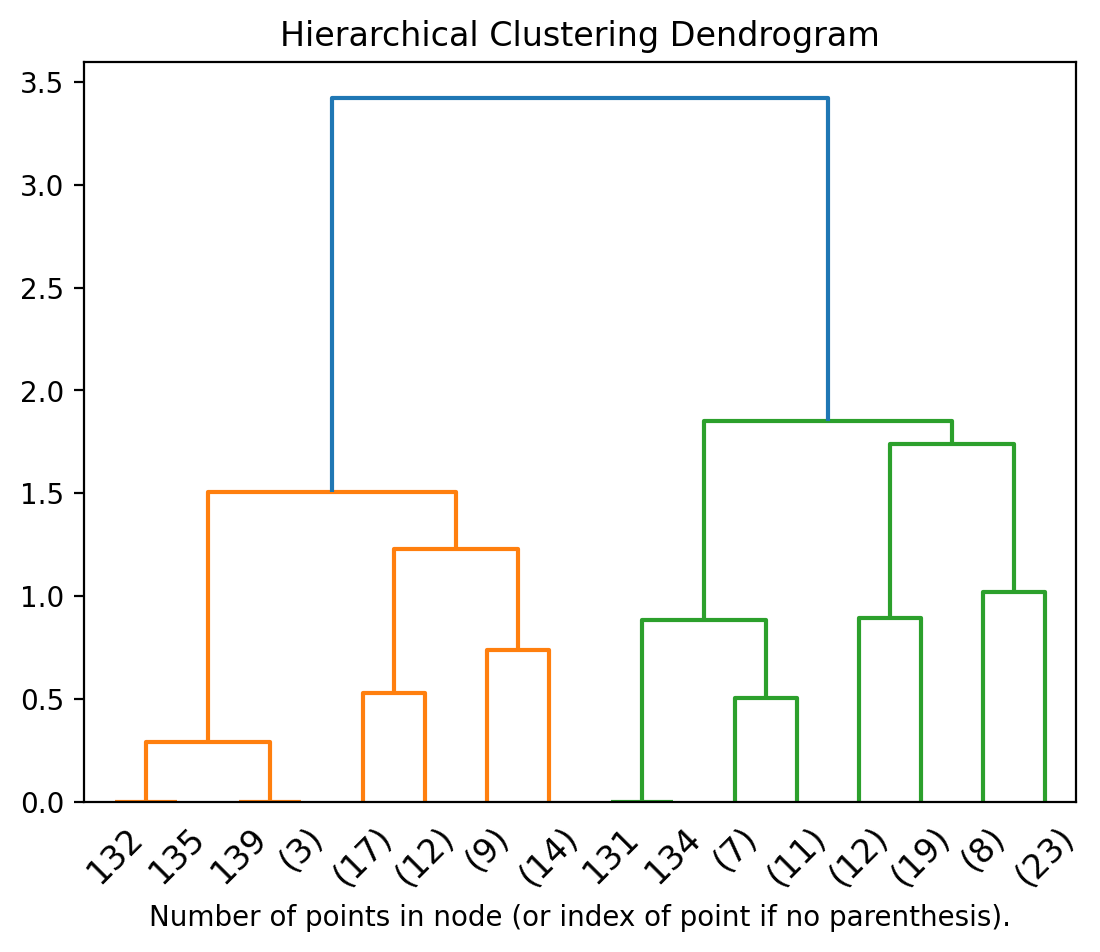

In [275]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram

from sklearn.cluster import AgglomerativeClustering
from sklearn.datasets import load_iris

def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)


X = np.stack(notes_vectors['vec'].values)

# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

model = model.fit(X)
plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(model, truncate_mode="level", p=3)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.xticks(rotation=45)
plt.show()